In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки для графиков и отображения
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# ==============================================================================
# ЯЧЕЙКА 1: Импорт библиотек
# ==============================================================================

# Библиотека для работы с массивами чисел
import numpy as np

# Библиотека для работы с таблицами данных (датафреймами)
import pandas as pd

# Библиотеки для построения красивых графиков и схем
import matplotlib.pyplot as plt
import seaborn as sns

# Из библиотеки машинного обучения sklearn импортируем:
# 1. DecisionTreeRegressor — само дерево решений для задачи регрессии (прогнозирования чисел)
# 2. plot_tree — специальная функция, которая рисует дерево как наглядную блок-схему
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Метрики качества регрессии:
# MSE — среднеквадратичная ошибка (штрафует за сильные промахи)
# MAE — средняя абсолютная ошибка (понятна человеку: на сколько в среднем ошиблись)
# R2  — коэффициент детерминации (показывает, какой процент разброса объяснила модель)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Функция для честного деления выборки на обучение (Train) и проверку (Test)
from sklearn.model_selection import train_test_split

# Настраиваем стиль графиков: белая сетка, крупный шрифт
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Ячейка 1 успешно выполнена! Все библиотеки готовы к работе.")

Ячейка 1 успешно выполнена! Все библиотеки готовы к работе.


In [3]:
# ==============================================================================
# ЯЧЕЙКА 2: Загрузка и предобработка датасета
# ==============================================================================

# Читаем CSV-файл в таблицу pandas
df = pd.read_csv('stroke_data.csv')

# Посмотрим исходный размер (строк, колонок)
print(f"Исходный размер таблицы: {df.shape}")

# 1. Колонка 'id' — это просто порядковый номер пациента в больнице.
# Она никакой полезной информации для прогнозирования не несет, поэтому удаляем ее:
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 2. В колонке 'bmi' (индекс массы тела) у некоторых пациентов стоят пропуски (NaN).
# Заполним эти пустые ячейки медианным (типичным) значением bmi:
if df['bmi'].isnull().sum() > 0:
    median_bmi = df['bmi'].median()
    df['bmi'] = df['bmi'].fillna(median_bmi)
    print(f"Пропуски в 'bmi' успешно заполнены медианой: {median_bmi:.1f}")

# 3. В признаке 'gender' (пол) есть ровно одна редкая строчка со значением 'Other'.
# Чтобы она не создавала лишних проблем, просто уберем эту одну строку:
df = df[df['gender'] != 'Other']

# 4. Кодируем текстовые колонки в цифры (One-Hot Encoding).
# Например, признак ever_married со значениями 'Yes'/'No' превратится в 1 и 0.
# drop_first=True убирает избыточные колонки (если не женат — это автоматически 0).
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Размер после кодирования категорий: {df_encoded.shape}")

# Выведем первые 5 строк получившейся таблицы, чтобы убедиться, что кругом только числа:
df_encoded.head()

Исходный размер таблицы: (5110, 12)
Пропуски в 'bmi' успешно заполнены медианой: 28.1
Размер после кодирования категорий: (5109, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


In [4]:
# ==============================================================================
# ЯЧЕЙКА 3: Подготовка обучающей и тестовой выборок для регрессии
# ==============================================================================

# X_reg — таблица со всеми характеристиками пациентов КРОМЕ уровня глюкозы
X_reg = df_encoded.drop(columns=['avg_glucose_level'])

# y_reg — колонка с правильными ответами (уровень глюкозы), которую мы учимся угадывать
y_reg = df_encoded['avg_glucose_level']

# Делим данные:
# test_size=0.2 — 20% пациентов оставляем для честного экзамена (теста)
# random_state=42 — чтобы при каждом перезапуске разбиение было одинаковым
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Пациентов для обучения (Train): {X_train_reg.shape[0]}")
print(f"Пациентов для экзамена (Test):    {X_test_reg.shape[0]}")

Пациентов для обучения (Train): 4087
Пациентов для экзамена (Test):    1022


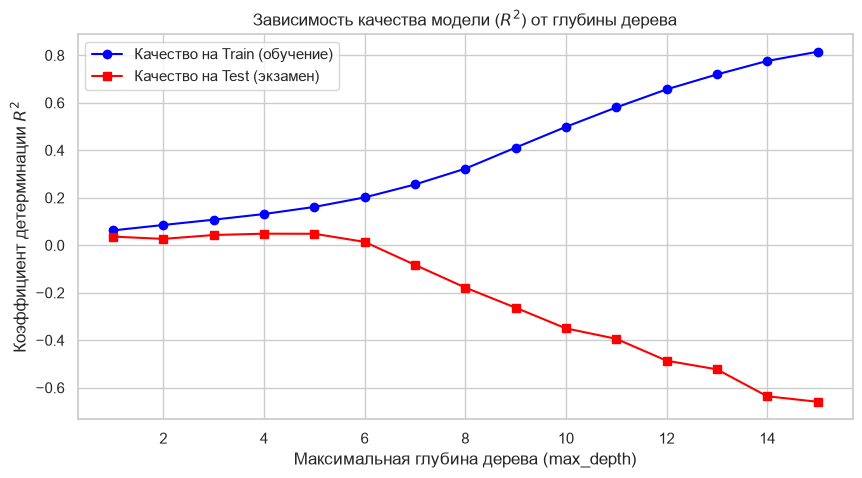

In [5]:
# ==============================================================================
# ЯЧЕЙКА 4: Исследование переобучения при разной глубине дерева (max_depth)
# ==============================================================================

depth_values = range(1, 16) # Проверим глубины от 1 до 15
train_scores = []           # Сюда будем сохранять R^2 на тренировочных данных
test_scores = []            # Сюда будем сохранять R^2 на тестовых данных

for d in depth_values:
    # 1. Создаем дерево с текущим ограничением глубины:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    
    # 2. Обучаем его на тренировочной выборке:
    model.fit(X_train_reg, y_train_reg)
    
    # 3. Делаем прогноз для тех данных, на которых дерево училось:
    pred_train = model.predict(X_train_reg)
    train_scores.append(r2_score(y_train_reg, pred_train))
    
    # 4. Делаем прогноз для новых данных (тестовых):
    pred_test = model.predict(X_test_reg)
    test_scores.append(r2_score(y_test_reg, pred_test))

# Строим график переобучения:
plt.figure(figsize=(10, 5))
plt.plot(depth_values, train_scores, marker='o', color='blue', label='Качество на Train (обучение)')
plt.plot(depth_values, test_scores, marker='s', color='red', label='Качество на Test (экзамен)')

plt.title('Зависимость качества модели ($R^2$) от глубины дерева')
plt.xlabel('Максимальная глубина дерева (max_depth)')
plt.ylabel('Коэффициент детерминации $R^2$')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# ==============================================================================
# ЯЧЕЙКА 5: Обучение оптимальной модели регрессии и расчет ошибок
# ==============================================================================

# Создаем сбалансированное дерево глубиной 3
optimal_reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
optimal_reg_tree.fit(X_train_reg, y_train_reg)

# Делаем прогноз на тестовых данных
y_pred_reg = optimal_reg_tree.predict(X_test_reg)

# Считаем стандартные метрики регрессии:
mae_val = mean_absolute_error(y_test_reg, y_pred_reg)
mse_val = mean_squared_error(y_test_reg, y_pred_reg)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_test_reg, y_pred_reg)

print("=" * 50)
print("РЕЗУЛЬТАТЫ РЕГРЕССИОННОГО ДЕРЕВА (max_depth=3):")
print("=" * 50)
print(f"MAE  (средняя абсолютная ошибка):    {mae_val:.2f} мг/дл")
print(f"MSE  (среднеквадратичная ошибка):    {mse_val:.2f}")
print(f"RMSE (корень из среднеквадратичной): {rmse_val:.2f} мг/дл")
print(f"R²   (коэффициент детерминации):     {r2_val:.4f}")
print("=" * 50)

РЕЗУЛЬТАТЫ РЕГРЕССИОННОГО ДЕРЕВА (max_depth=3):
MAE  (средняя абсолютная ошибка):    32.60 мг/дл
MSE  (среднеквадратичная ошибка):    1913.04
RMSE (корень из среднеквадратичной): 43.74 мг/дл
R²   (коэффициент детерминации):     0.0430


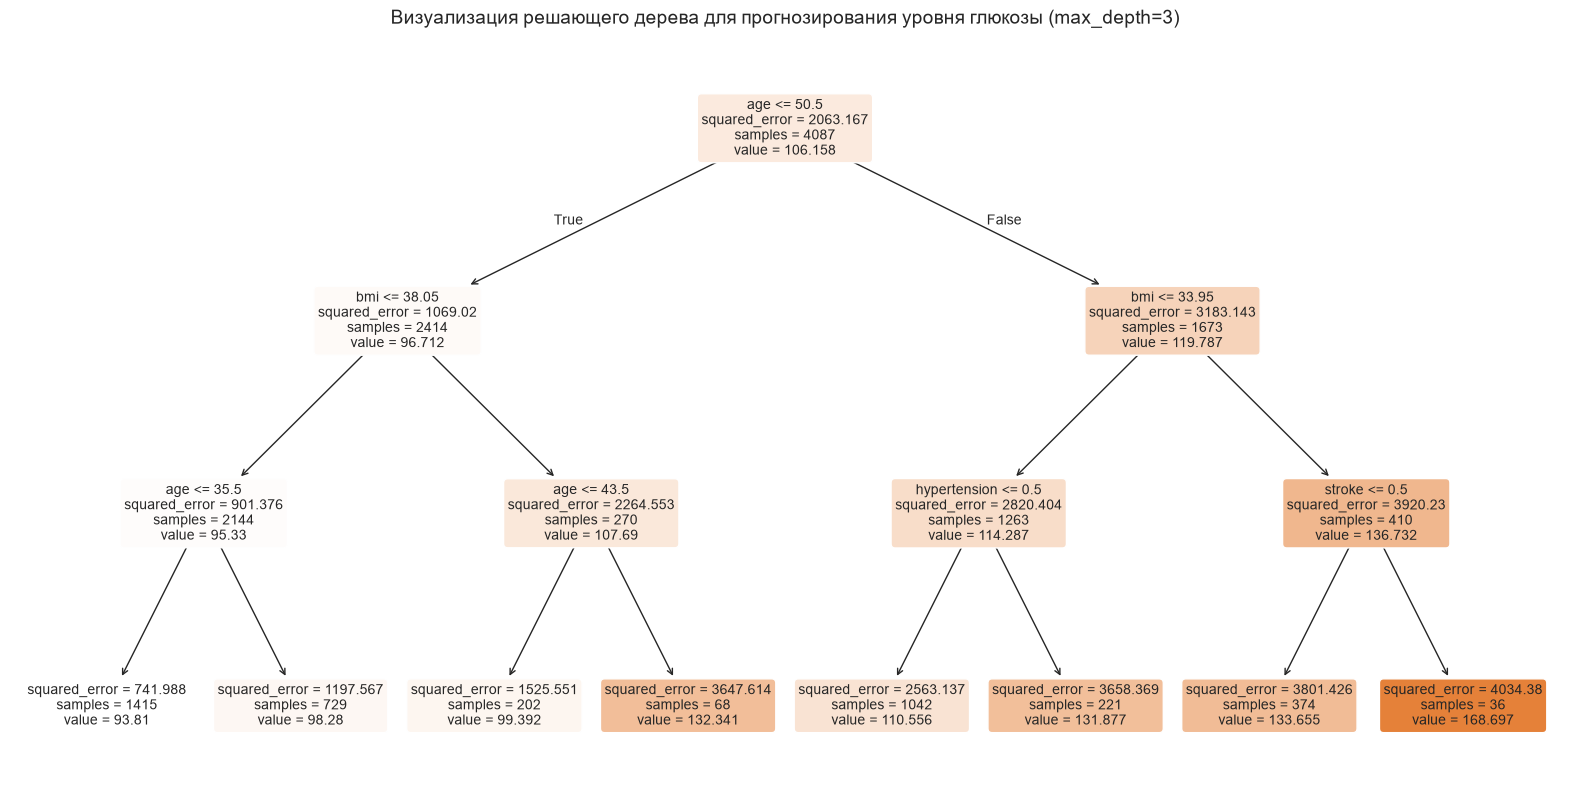

In [7]:
# ==============================================================================
# ЯЧЕЙКА 6: Отрисовка дерева решений в виде блок-схемы
# ==============================================================================

plt.figure(figsize=(20, 10))

plot_tree(
    optimal_reg_tree,
    feature_names=X_reg.columns,  # Подписываем названия признаков (age, bmi и т.д.)
    filled=True,                  # Раскрашиваем узлы цветом в зависимости от величины прогноза
    rounded=True,                 # Скругляем углы блоков для красоты
    fontsize=10                   # Размер шрифта текста внутри блоков
)

plt.title("Визуализация решающего дерева для прогнозирования уровня глюкозы (max_depth=3)", fontsize=14)
plt.show()

In [8]:
# ==============================================================================
# ЯЧЕЙКА 7: Подготовка данных для бинарной классификации инсульта
# ==============================================================================

# X_clf — все характеристики пациента КРОМЕ целевой колонки 'stroke'
X_clf = df_encoded.drop(columns=['stroke'])

# y_clf — целевая переменная (0 — нет инсульта, 1 — есть инсульт)
y_clf = df_encoded['stroke']

# Посмотрим на соотношение классов в датасете:
counts = y_clf.value_counts()
print(f"Здоровых пациентов (0): {counts[0]} ({counts[0]/len(y_clf)*100:.1f}%)")
print(f"Пациентов с инсультом (1): {counts[1]} ({counts[1]/len(y_clf)*100:.1f}%)")

# Разделяем выборку на обучающую (80%) и тестовую (20%).
# Параметр stratify=y_clf ОБЯЗАТЕЛЕН при дисбалансе: он гарантирует,
# что и в обучении, и в тесте будет одинаковая пропорция больных пациентов!
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"\nОбучающая выборка: {X_train_clf.shape[0]} записей")
print(f"Тестовая выборка:   {X_test_clf.shape[0]} записей")

Здоровых пациентов (0): 4860 (95.1%)
Пациентов с инсультом (1): 249 (4.9%)

Обучающая выборка: 4087 записей
Тестовая выборка:   1022 записей


In [11]:
# ==============================================================================
# ЯЧЕЙКА 8: Обучение дерева классификации и расчет вероятностей
# ==============================================================================

# Импортируем сам классификатор из библиотеки sklearn
from sklearn.tree import DecisionTreeClassifier

# 1. Создаем модель дерева решений:
# - max_depth=4: ограничиваем глубину для предотвращения переобучения (pre-pruning)
# - criterion='gini': критерий Джини (по умолчанию в scikit-learn, стр. 6-7 методички)
# - class_weight='balanced': помогает дереву обращать внимание на редкий класс 1 (инсульт)
dt_classifier = DecisionTreeClassifier(
    max_depth=4, 
    criterion='gini',
    class_weight='balanced', 
    random_state=42
)

# 2. Обучаем дерево на тренировочной выборке
dt_classifier.fit(X_train_clf, y_train_clf)

# 3. Делаем обычный прогноз классов (0 или 1) при стандартном пороге 0.5
y_pred_clf = dt_classifier.predict(X_test_clf)

# 4. Получаем ВЕРОЯТНОСТИ (как написано на стр. 12 методички):
# Метод predict_proba возвращает две колонки: [вероятность_0, вероятность_1].
# Нам нужна именно вторая колонка [:, 1] — вероятность класса 1 (риск инсульта).
y_proba_clf = dt_classifier.predict_proba(X_test_clf)[:, 1]

print("Модель обучена, вероятности успешно вычислены!")
print(f"Пример вероятностей инсульта для первых 5 пациентов: \n{y_proba_clf[:5].round(3)}")

Модель обучена, вероятности успешно вычислены!
Пример вероятностей инсульта для первых 5 пациентов: 
[0.   0.   0.57 0.   0.57]


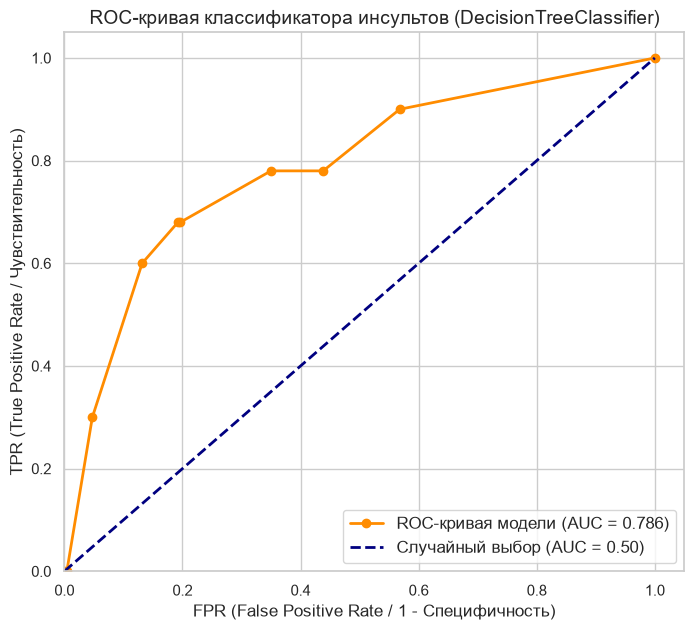

Итоговое значение метрики ROC-AUC: 0.7864


In [13]:
# ==============================================================================
# ЯЧЕЙКА 9: Построение ROC-кривой и расчет площади ROC-AUC (стр. 15 методички)
# ==============================================================================

# Импортируем функции для ROC-кривой и площади под ней
from sklearn.metrics import roc_curve, auc

# Считаем точки для ROC-кривой:
# fpr — False Positive Rate (доля ложных тревог по оси X)
# tpr — True Positive Rate (чувствительность / полнота по оси Y)
# thresholds — пороги отсечения, которые алгоритм перебирал от 1.0 до 0.0
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_clf)

# Вычисляем площадь под кривой (ROC-AUC)
auc_score = auc(fpr, tpr)

# Отрисовываем график (код адаптирован со страницы 15 методички)
plt.figure(figsize=(8, 7))

# 1. Рисуем кривую нашей модели
plt.plot(fpr, tpr, marker='o', color='darkorange', lw=2, 
         label=f'ROC-кривая модели (AUC = {auc_score:.3f})')

# 2. Рисуем диагональ случайного угадывания (базовый уровень 50/50, как на стр. 14-15)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный выбор (AUC = 0.50)')

# Настройки осей и заголовков (в точности по методичке)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (False Positive Rate / 1 - Специфичность)', fontsize=12)
plt.ylabel('TPR (True Positive Rate / Чувствительность)', fontsize=12)
plt.title('ROC-кривая классификатора инсультов (DecisionTreeClassifier)', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

print(f"Итоговое значение метрики ROC-AUC: {auc_score:.4f}")

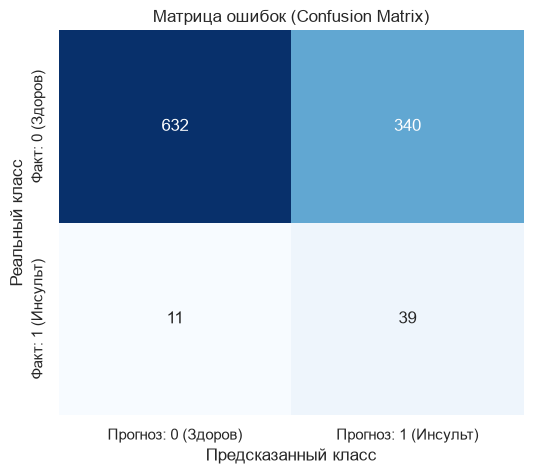


Подробный отчет по метрикам (Classification Report):
              precision    recall  f1-score   support

  Здоров (0)       0.98      0.65      0.78       972
 Инсульт (1)       0.10      0.78      0.18        50

    accuracy                           0.66      1022
   macro avg       0.54      0.72      0.48      1022
weighted avg       0.94      0.66      0.75      1022



In [14]:
# ==============================================================================
# ЯЧЕЙКА 10: Детальная оценка классификации (Precision, Recall, Confusion Matrix)
# ==============================================================================
from sklearn.metrics import confusion_matrix, classification_report

# Строим матрицу ошибок:
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Прогноз: 0 (Здоров)', 'Прогноз: 1 (Инсульт)'],
            yticklabels=['Факт: 0 (Здоров)', 'Факт: 1 (Инсульт)'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.show()

# Печатаем текстовый отчет по классам
print("\nПодробный отчет по метрикам (Classification Report):")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Здоров (0)', 'Инсульт (1)']))

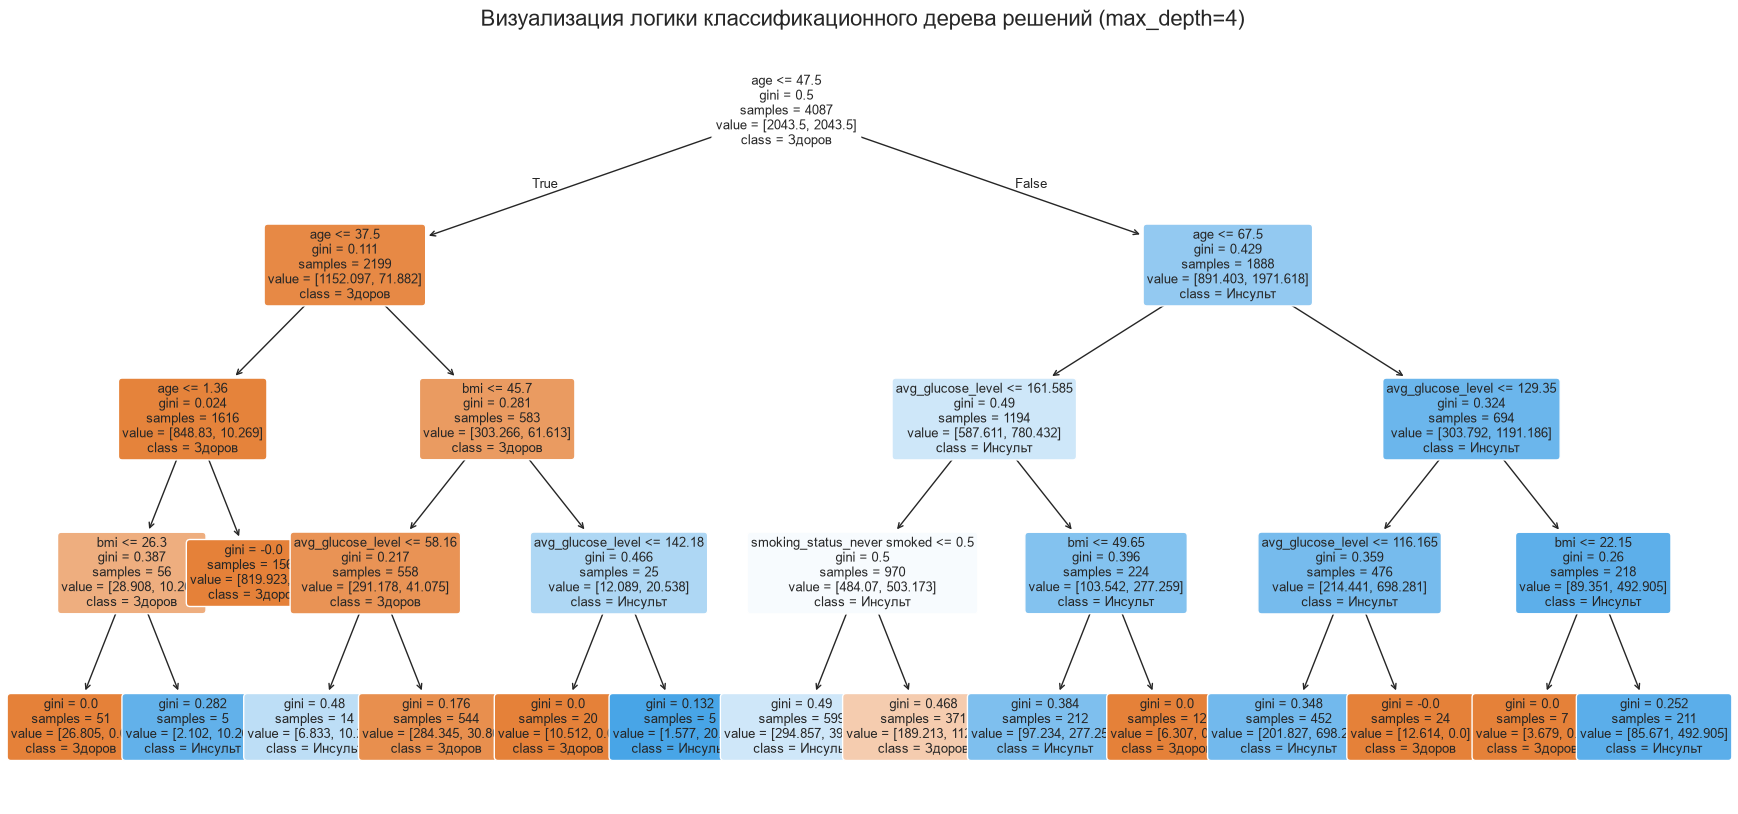

In [15]:
# ==============================================================================
# ЯЧЕЙКА 11: Отрисовка дерева классификации
# ==============================================================================

plt.figure(figsize=(22, 10))

plot_tree(
    dt_classifier,
    feature_names=X_clf.columns,
    class_names=['Здоров', 'Инсульт'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Визуализация логики классификационного дерева решений (max_depth=4)", fontsize=16)
plt.show()